In [ ]:
"""03_EDA.ipynb

1. Project Title
2. Import Libraries
3. Load Cleaned Dataset
4. Dataset Overview
5. KPI Dashboard
6. Numerical Features
7. Categorical Features
8. Missing Values
9. Target Variable Analysis
10. Histograms
11. KDE Plots
12. Box Plots
13. Count Plots
14. Pie Charts
15. Correlation Heatmap
16. Pair Plot (Selected Features)
17. Credit Amount Analysis
18. Duration Analysis
19. Age Analysis
20. Risk vs Features
21. Outlier Analysis
22. Business Insights
23. Save Charts
24. Export Reports
25. Summary"""

In [ ]:
"""# 📊 Credit Risk Prediction System

# 03 - Exploratory Data Analysis (EDA)

---

## Objective

The purpose of this notebook is to explore the cleaned German Credit dataset using statistical analysis and visualizations.

EDA helps us understand:

- Customer demographics
- Credit behavior
- Risk distribution
- Feature relationships
- Potential predictors for the machine learning model

---

## Goals

- Understand numerical and categorical features
- Identify patterns and trends
- Detect outliers
- Analyze the target variable
- Generate business insights"""

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10,6)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# ==========================================================
# Load Cleaned Dataset
# ==========================================================

DATA_PATH = "../data/processed/cleaned_credit_data.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)

(1000, 11)


In [3]:
# ==========================================================
# Dataset Overview
# ==========================================================

print("="*60)

print("Rows :",df.shape[0])

print("Columns :",df.shape[1])

print("="*60)

df.head()

Rows : 1000
Columns : 11


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,No Account,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,No Account,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [4]:
# ==========================================================
# Dataset KPI Dashboard
# ==========================================================

total_customers = len(df)

average_age = round(df["Age"].mean(),1)

average_credit = round(df["Credit amount"].mean(),2)

average_duration = round(df["Duration"].mean(),1)

print("="*60)

print(f"Total Customers : {total_customers}")

print(f"Average Age : {average_age}")

print(f"Average Credit : {average_credit}")

print(f"Average Duration : {average_duration}")

print("="*60)

Total Customers : 1000
Average Age : 35.5
Average Credit : 3271.26
Average Duration : 20.9


In [5]:
numerical_columns = df.select_dtypes(

include=np.number

).columns.tolist()

numerical_columns

['Unnamed: 0', 'Age', 'Job', 'Credit amount', 'Duration']

In [6]:
categorical_columns = df.select_dtypes(

include="object"

).columns.tolist()

categorical_columns

['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose', 'Risk']

In [7]:
df.isnull().sum()

Unnamed: 0          0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

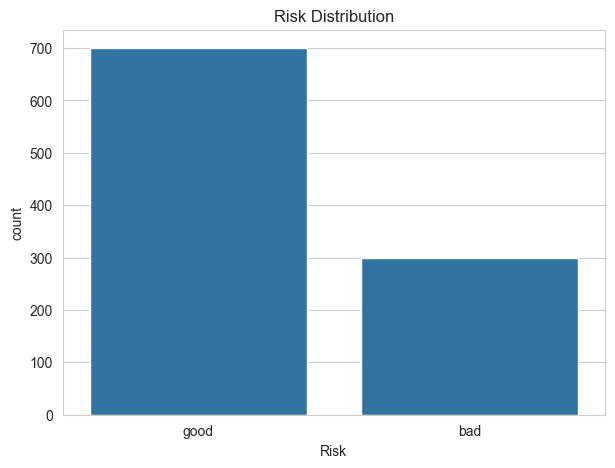

In [8]:
plt.figure(figsize=(7,5))

sns.countplot(

data=df,

x="Risk"

)

plt.title("Risk Distribution")

plt.show()

In [9]:
# ==========================================================
# Professional Plot Configuration
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

sns.set_theme(
    style="whitegrid",
    palette="Set2"
)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11

print("Visualization Style Loaded Successfully")

Visualization Style Loaded Successfully


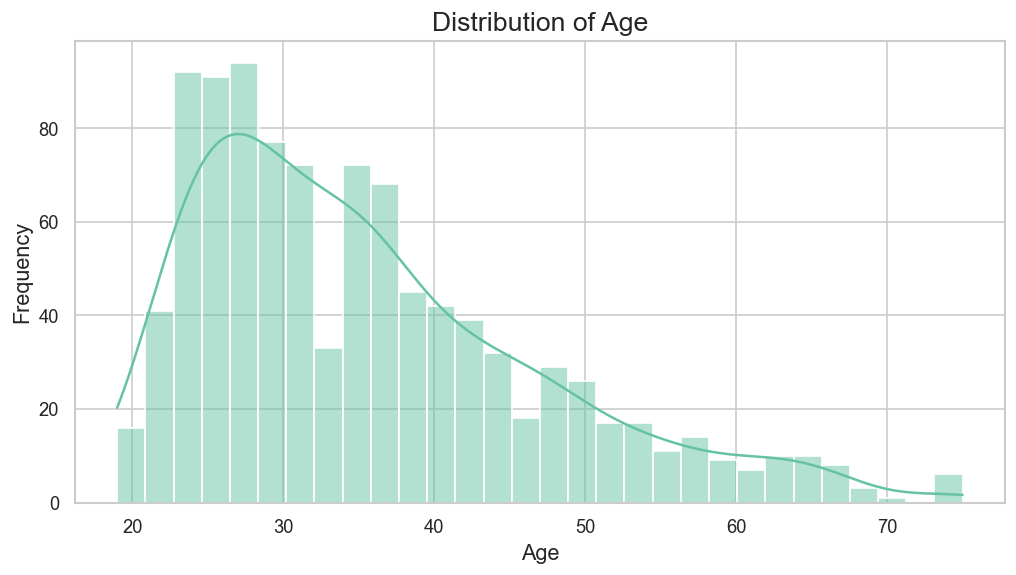

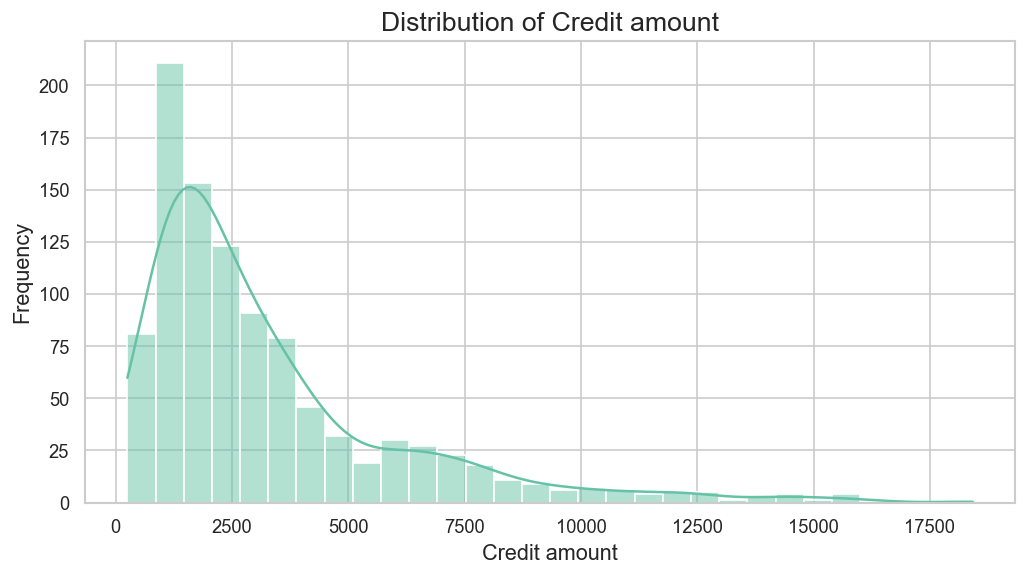

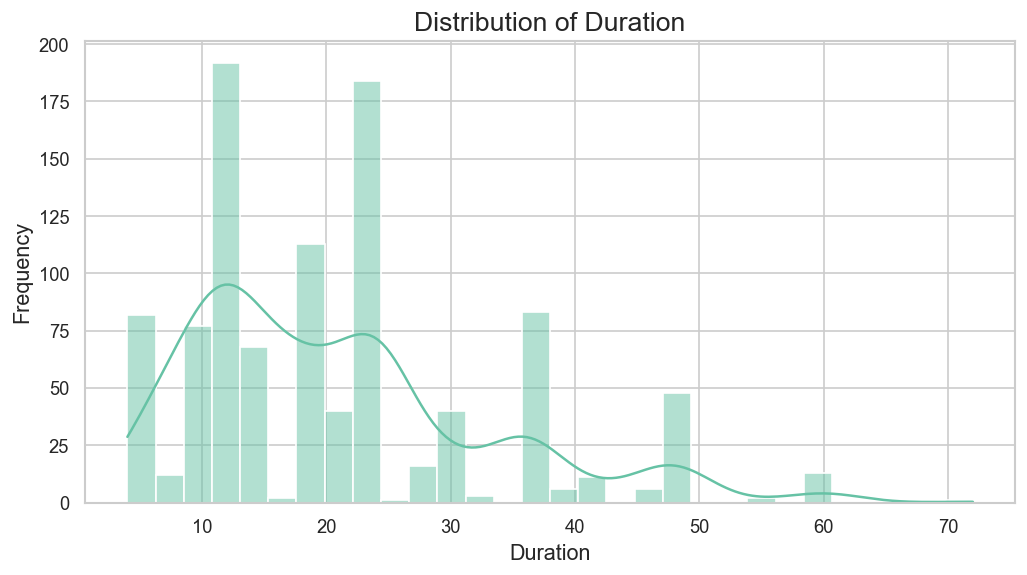

In [10]:
# ==========================================================
# Distribution of Numerical Features
# ==========================================================

numerical_columns = [
    "Age",
    "Credit amount",
    "Duration"
]

for column in numerical_columns:

    plt.figure(figsize=(10,5))

    sns.histplot(
        data=df,
        x=column,
        bins=30,
        kde=True
    )

    plt.title(f"Distribution of {column}")

    plt.xlabel(column)

    plt.ylabel("Frequency")

    plt.show()

In [ ]:
"""Business Insight
Age
Most applicants are young adults.
Credit Amount
Right-skewed.
Most loans are relatively small.
Duration
Most loans have shorter repayment periods."""

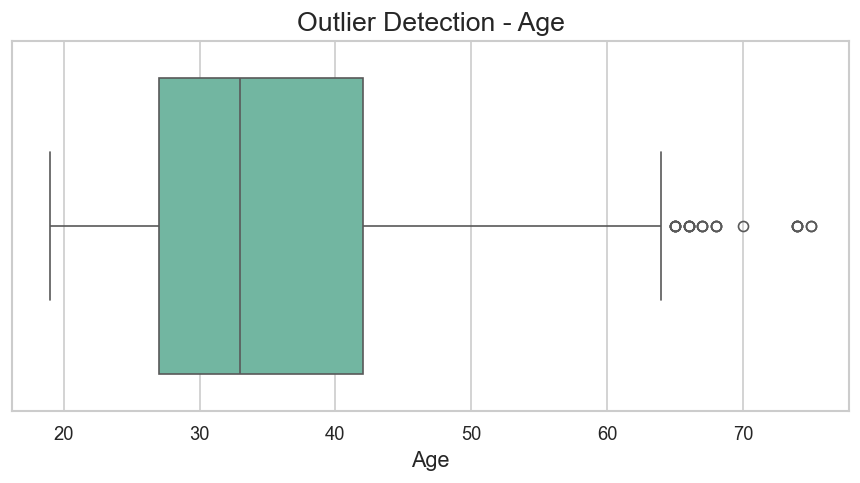

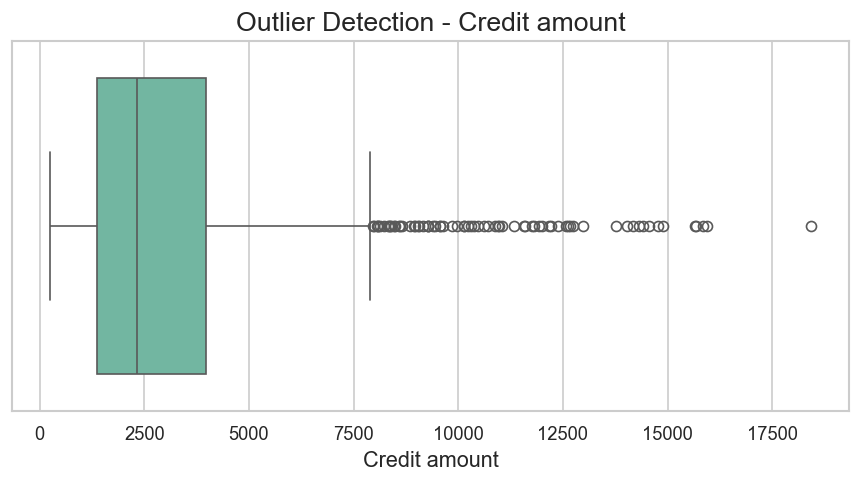

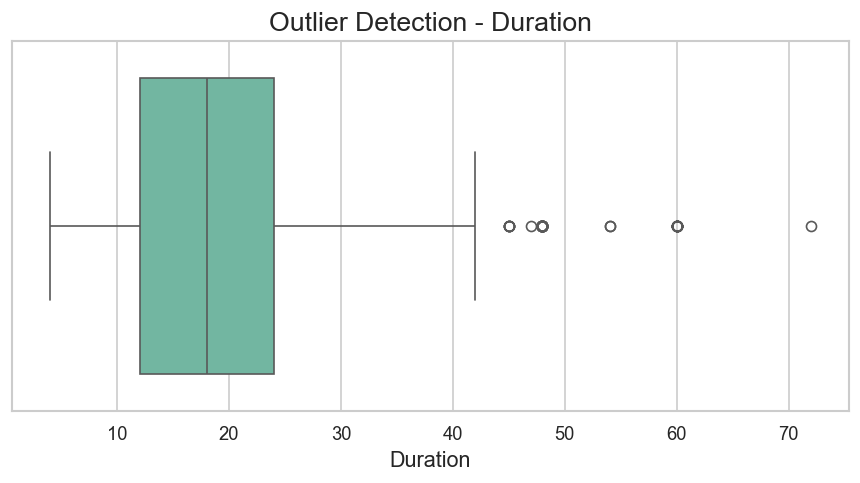

In [11]:
# ==========================================================
# Outlier Detection
# ==========================================================

for column in numerical_columns:

    plt.figure(figsize=(9,4))

    sns.boxplot(
        data=df,
        x=column
    )

    plt.title(f"Outlier Detection - {column}")

    plt.show()

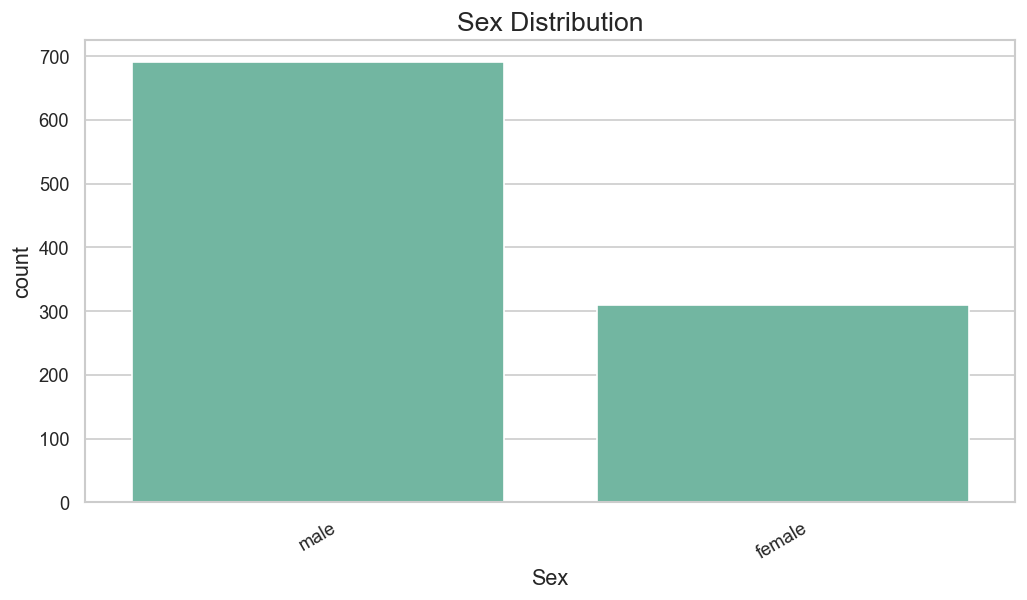

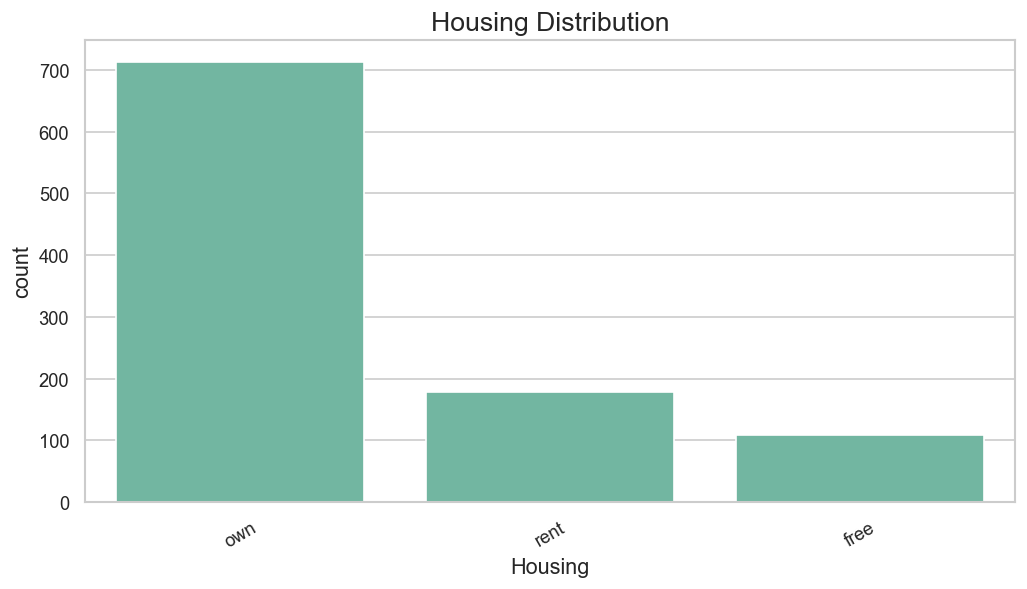

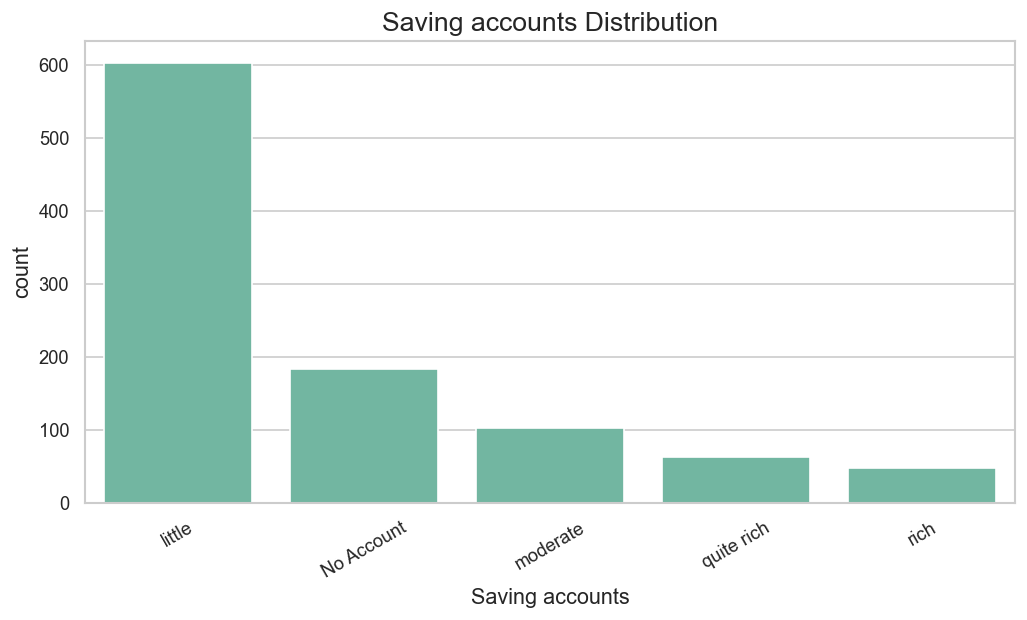

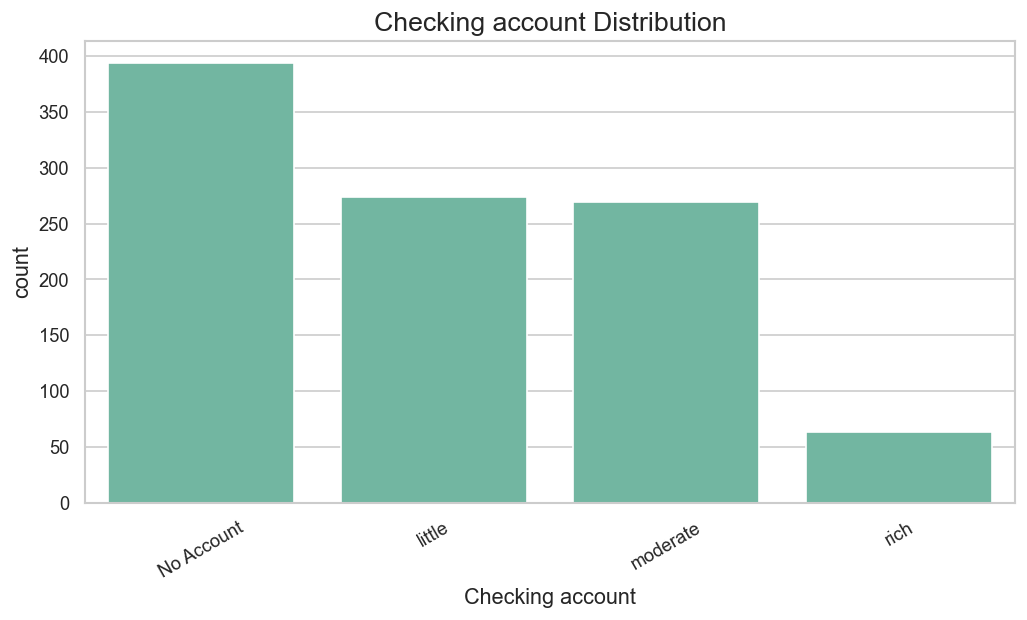

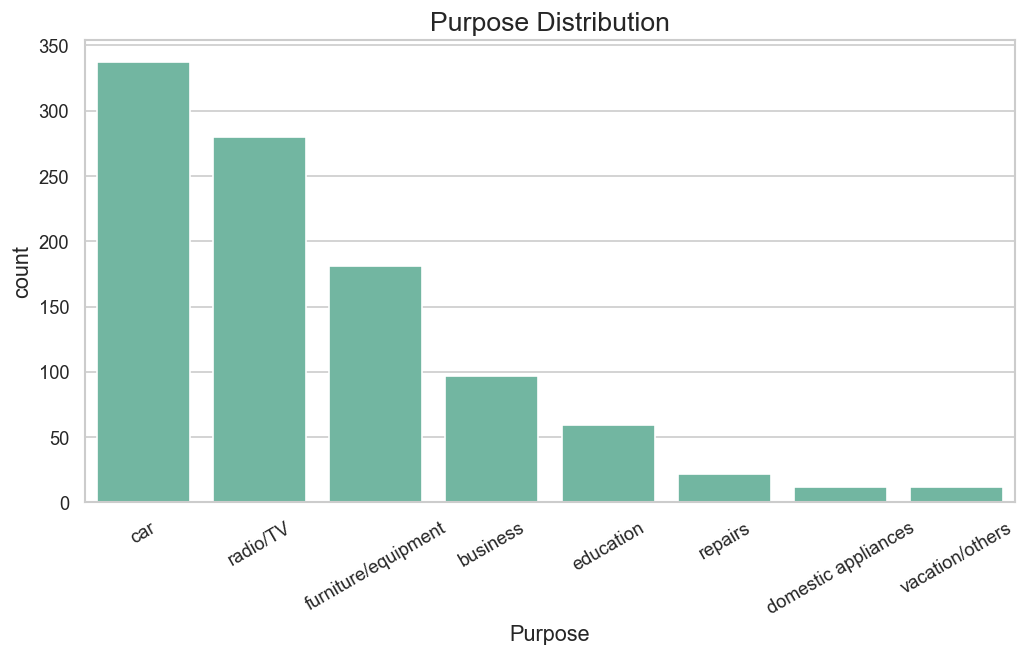

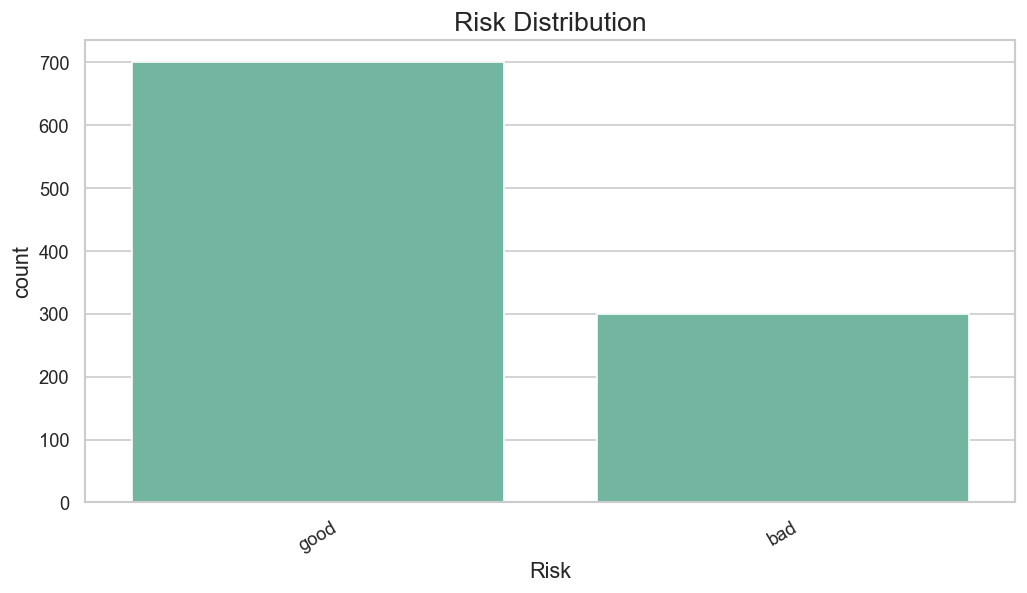

In [12]:
# ==========================================================
# Categorical Feature Distribution
# ==========================================================

categorical_columns = [
    "Sex",
    "Housing",
    "Saving accounts",
    "Checking account",
    "Purpose",
    "Risk"
]

for column in categorical_columns:

    plt.figure(figsize=(10,5))

    sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts().index
    )

    plt.title(f"{column} Distribution")

    plt.xticks(rotation=30)

    plt.show()

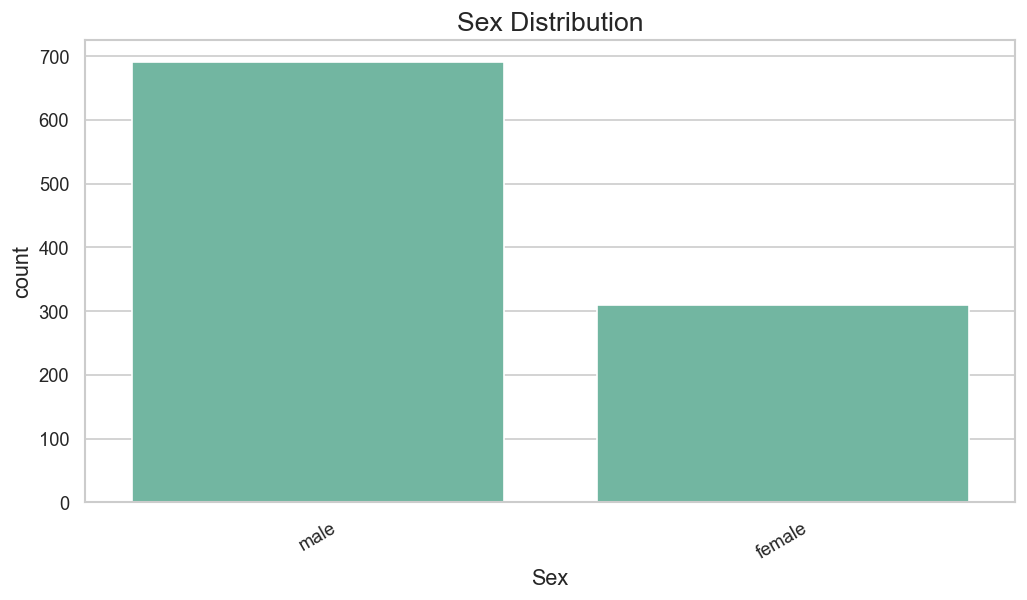

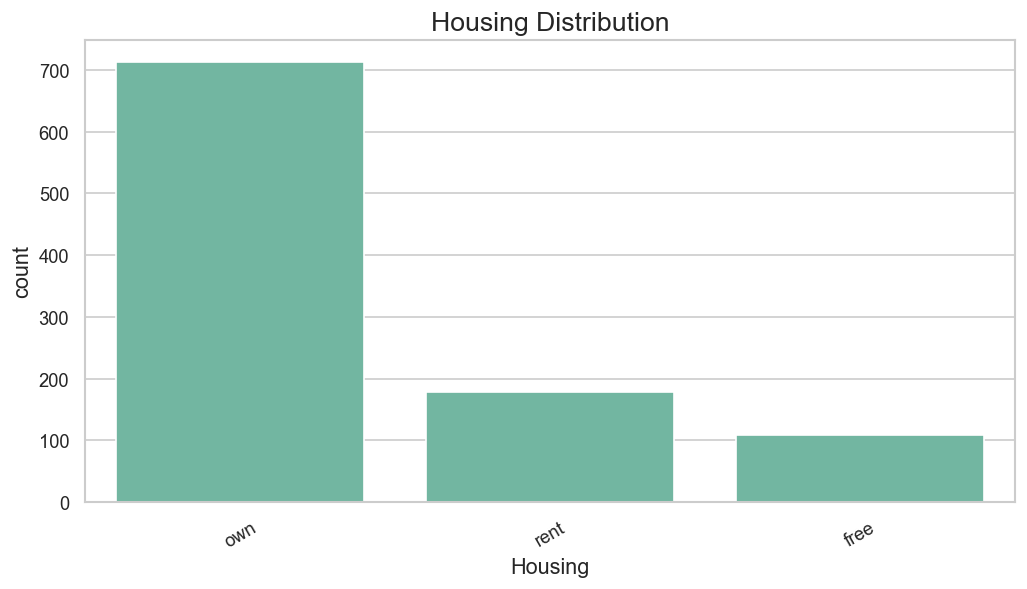

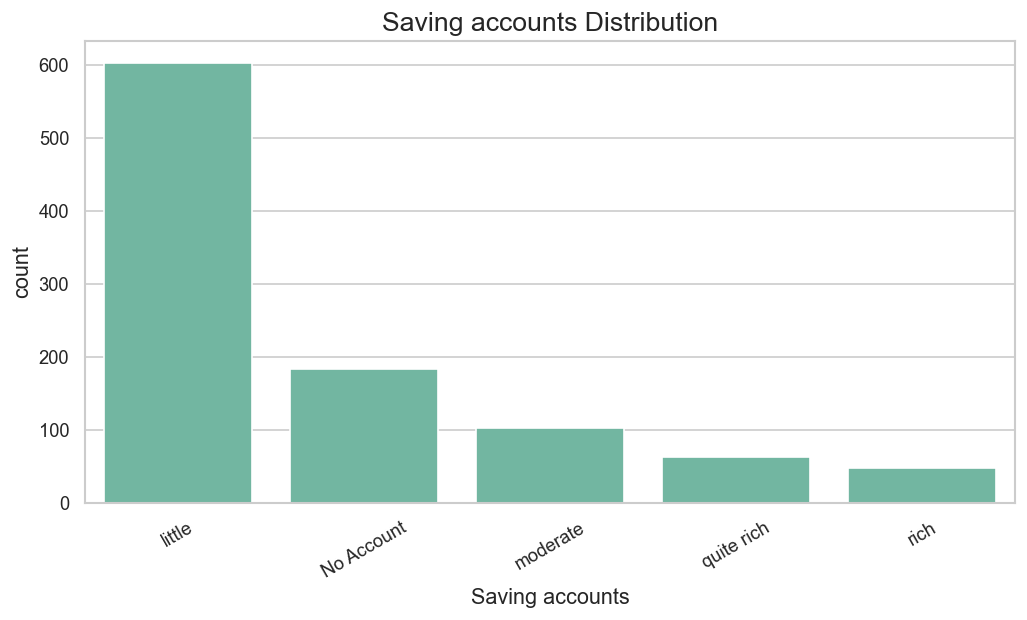

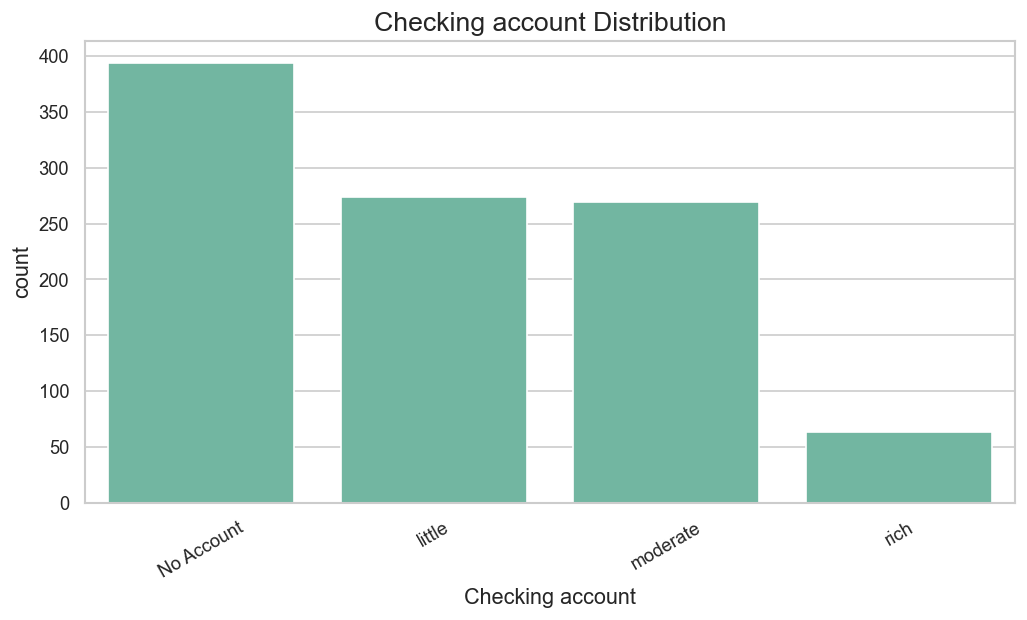

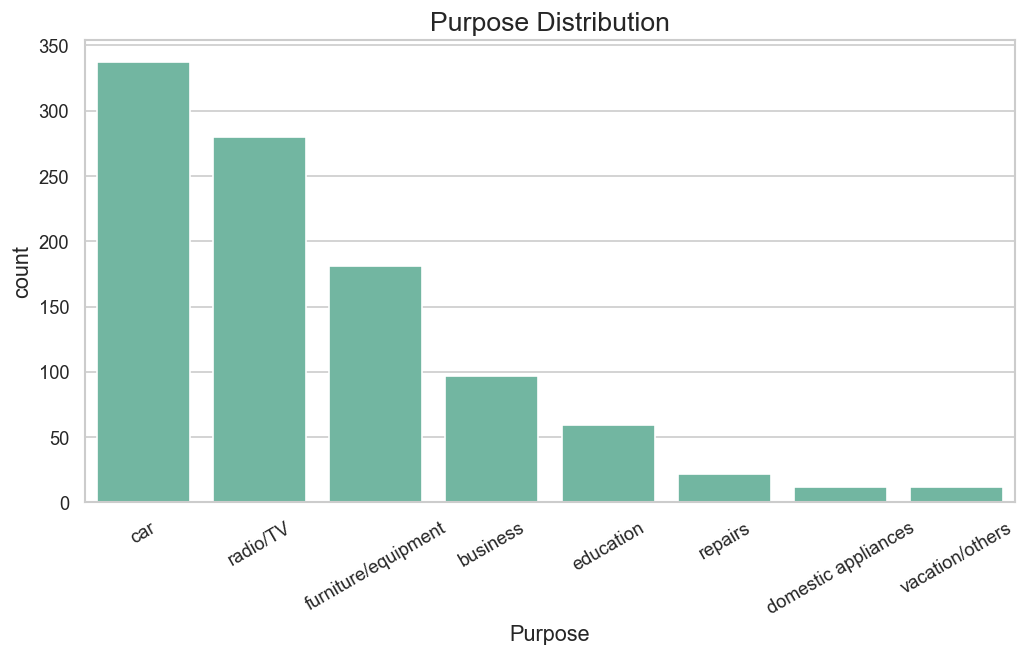

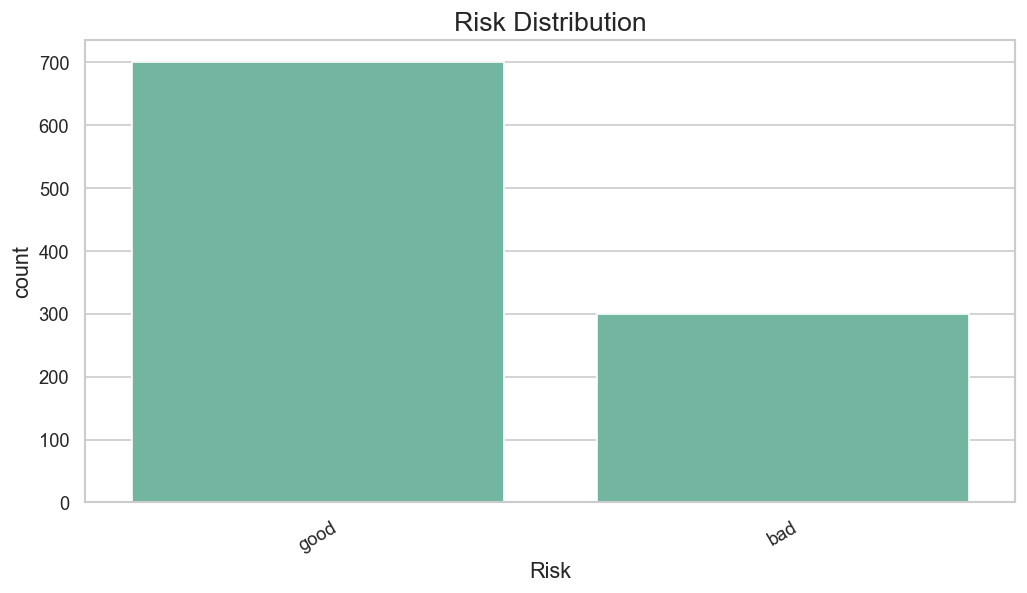

In [13]:
# ==========================================================
# Categorical Feature Distribution
# ==========================================================

categorical_columns = [
    "Sex",
    "Housing",
    "Saving accounts",
    "Checking account",
    "Purpose",
    "Risk"
]

for column in categorical_columns:

    plt.figure(figsize=(10,5))

    sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts().index
    )

    plt.title(f"{column} Distribution")

    plt.xticks(rotation=30)

    plt.show()

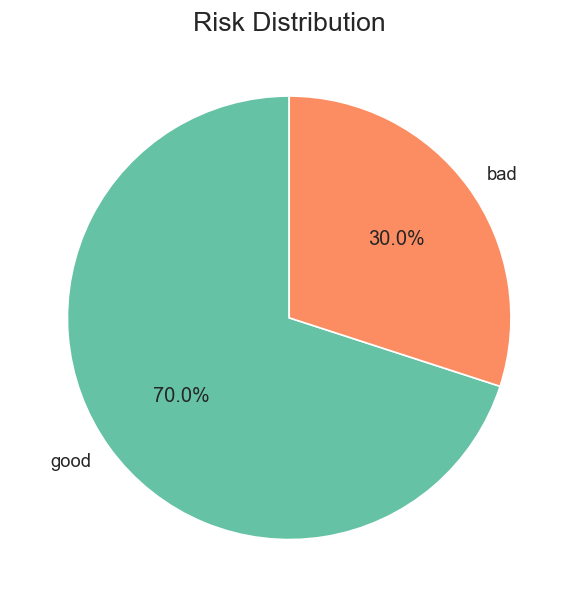

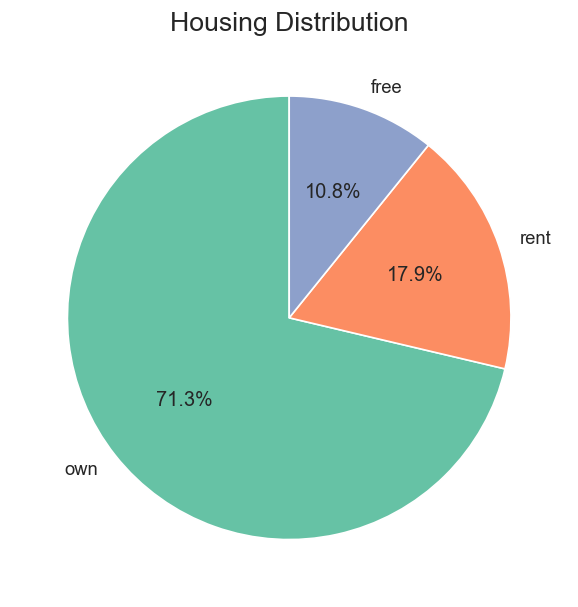

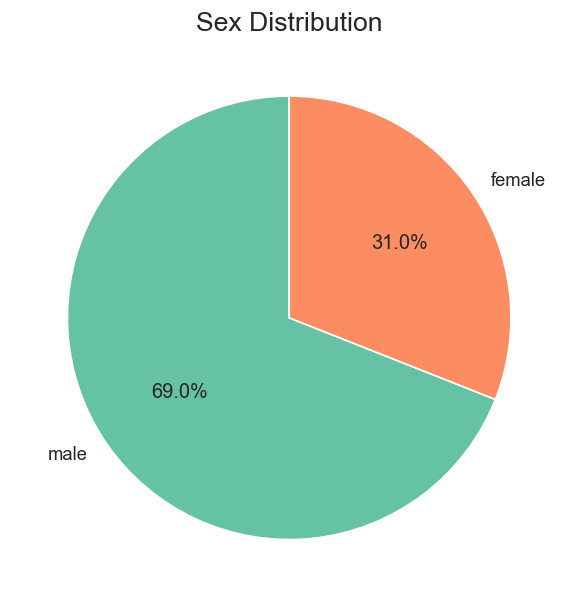

In [14]:
# ==========================================================
# Pie Charts
# ==========================================================

pie_columns = [
    "Risk",
    "Housing",
    "Sex"
]

for column in pie_columns:

    plt.figure(figsize=(6,6))

    df[column].value_counts().plot(
        kind="pie",
        autopct="%1.1f%%",
        startangle=90
    )

    plt.ylabel("")

    plt.title(f"{column} Distribution")

    plt.show()

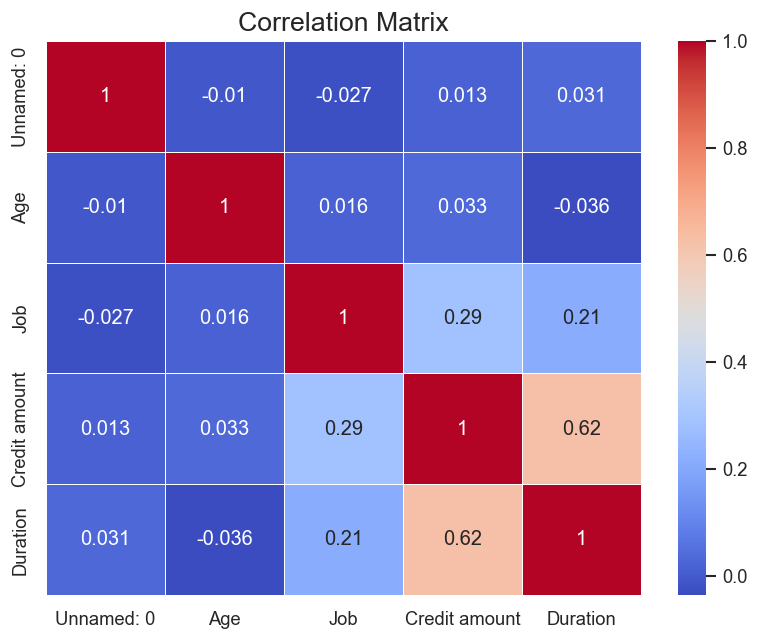

In [15]:
# ==========================================================
# Correlation Heatmap
# ==========================================================

plt.figure(figsize=(8,6))

correlation = df.select_dtypes(include="number").corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
"""Business Insight

The heatmap helps identify:

Strong positive relationships
Strong negative relationships
Potential multicollinearity

This is useful before feature engineering and model training."""

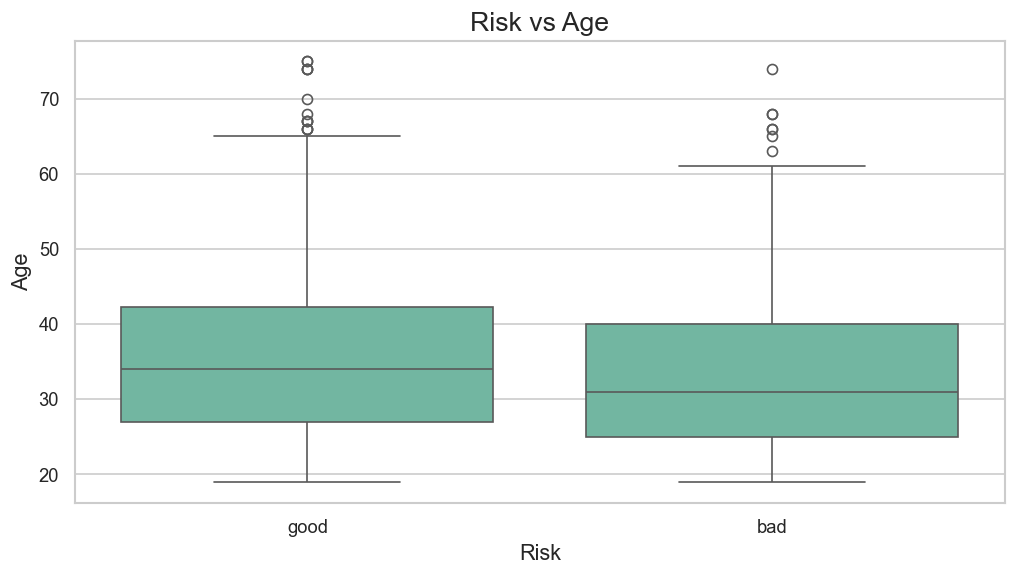

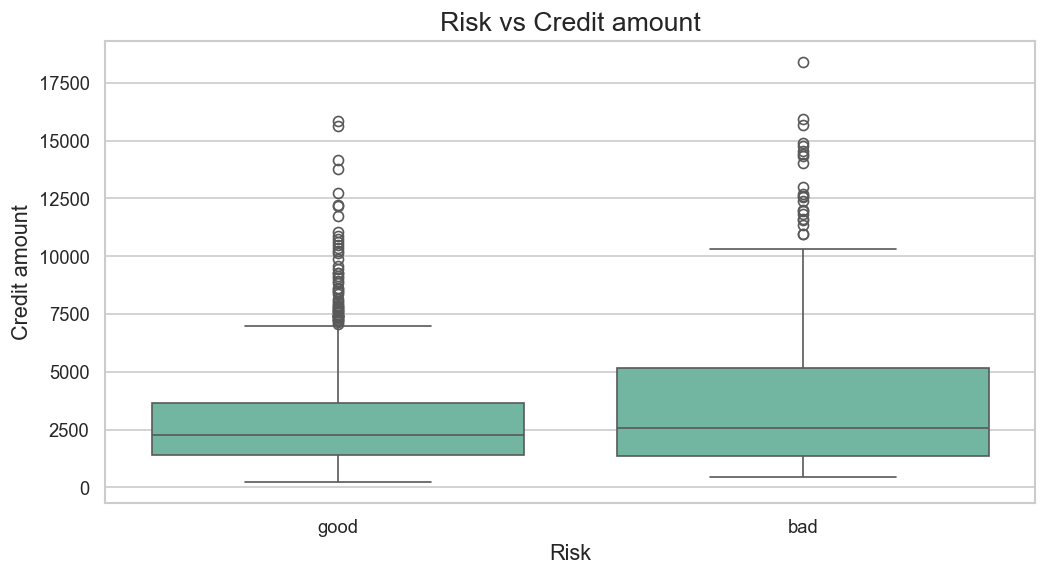

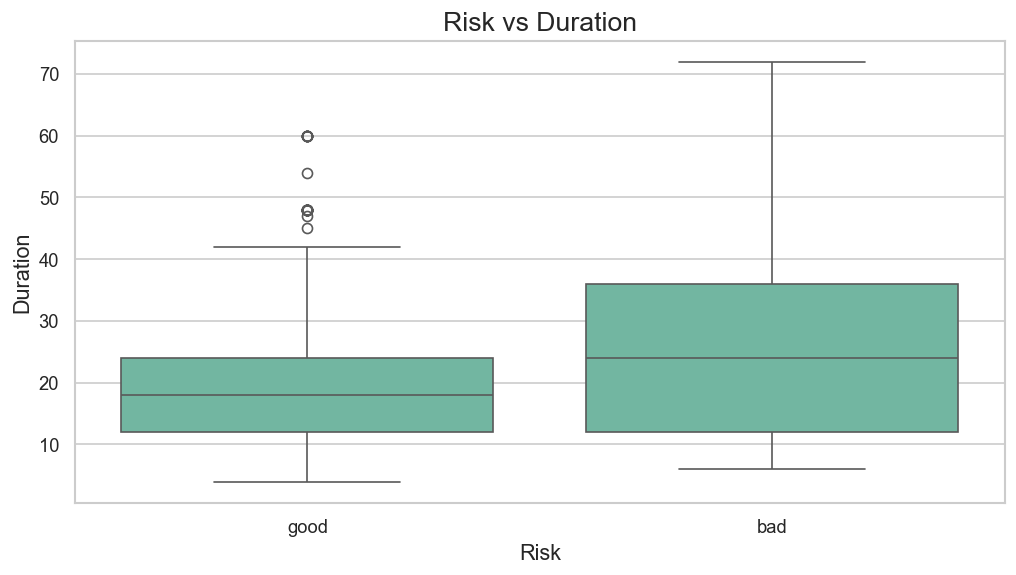

In [16]:
# ==========================================================
# Risk vs Numerical Features
# ==========================================================

for column in numerical_columns:

    plt.figure(figsize=(10,5))

    sns.boxplot(
        data=df,
        x="Risk",
        y=column
    )

    plt.title(f"Risk vs {column}")

    plt.show()

In [ ]:
"""Business Insight

These plots help answer questions like:

Do high-risk customers borrow more?
Are high-risk loans longer?
Does age differ between risk groups?"""

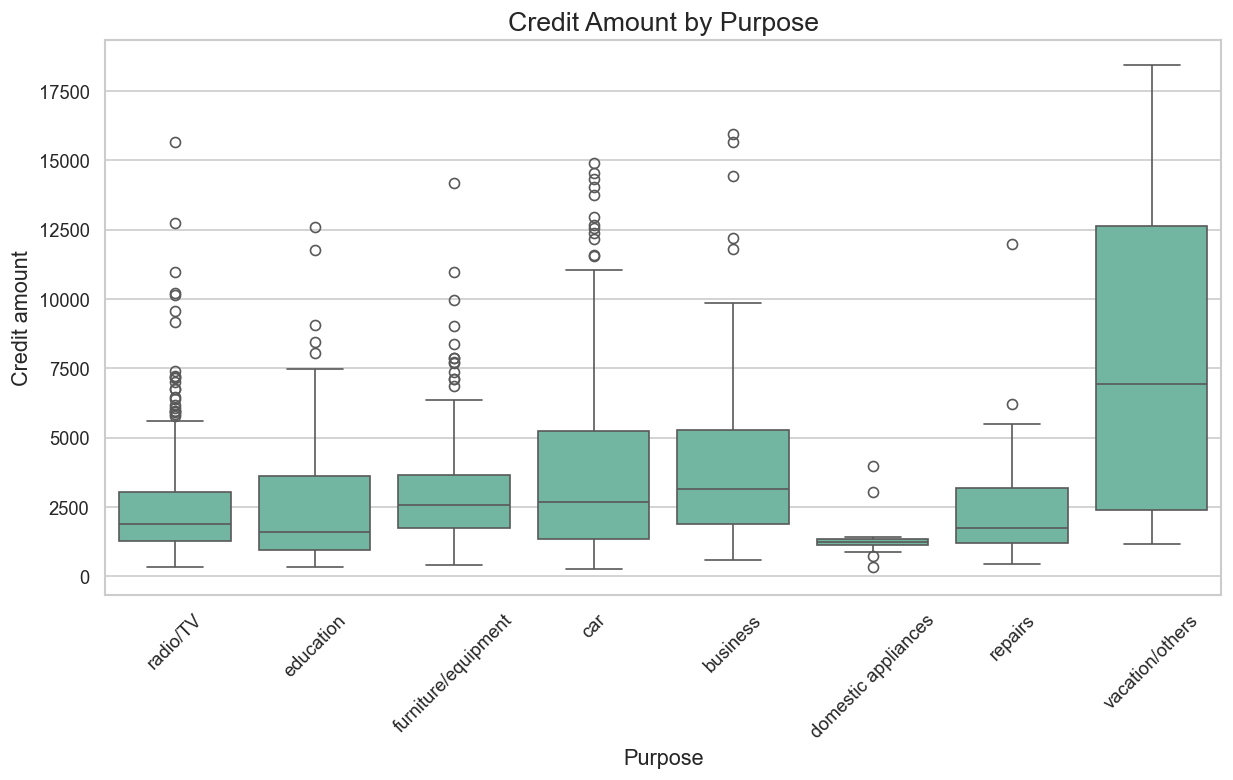

In [17]:
# ==========================================================
# Credit Amount by Purpose
# ==========================================================

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Purpose",
    y="Credit amount"
)

plt.xticks(rotation=45)

plt.title("Credit Amount by Purpose")

plt.show()

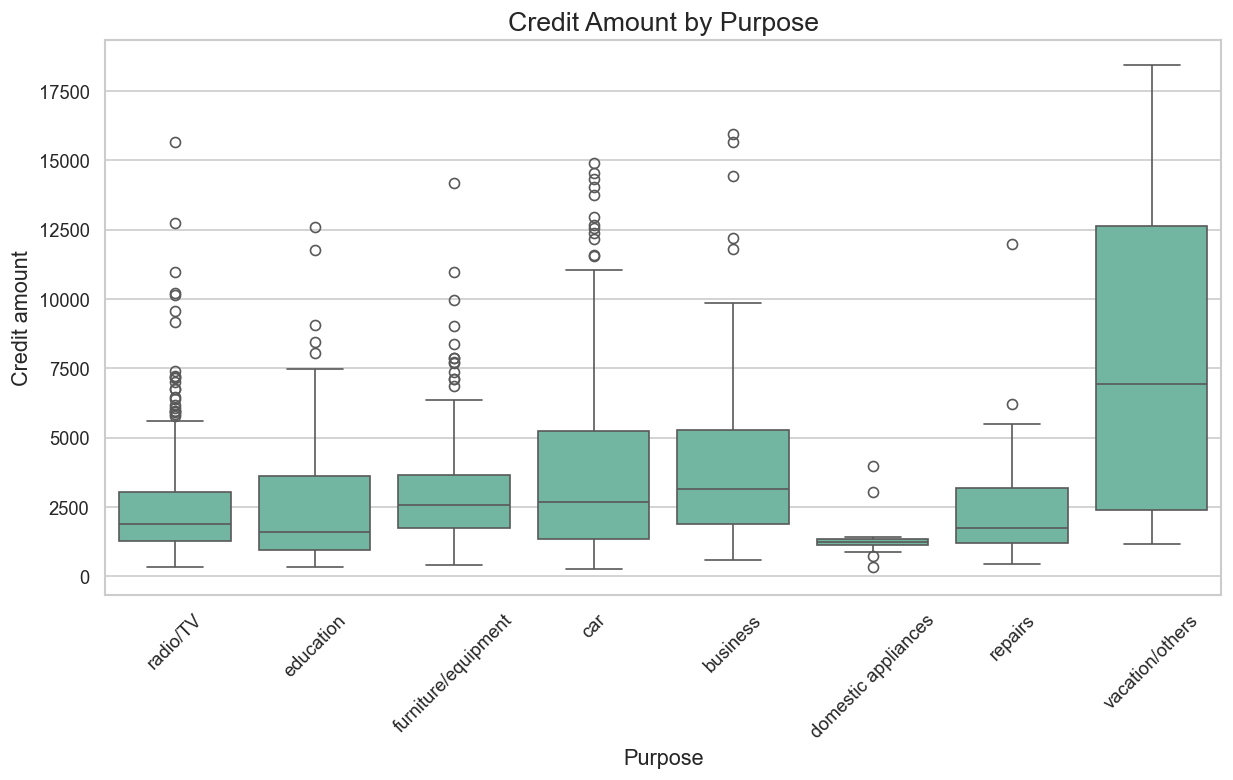

In [18]:
# ==========================================================
# Credit Amount by Purpose
# ==========================================================

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Purpose",
    y="Credit amount"
)

plt.xticks(rotation=45)

plt.title("Credit Amount by Purpose")

plt.show()

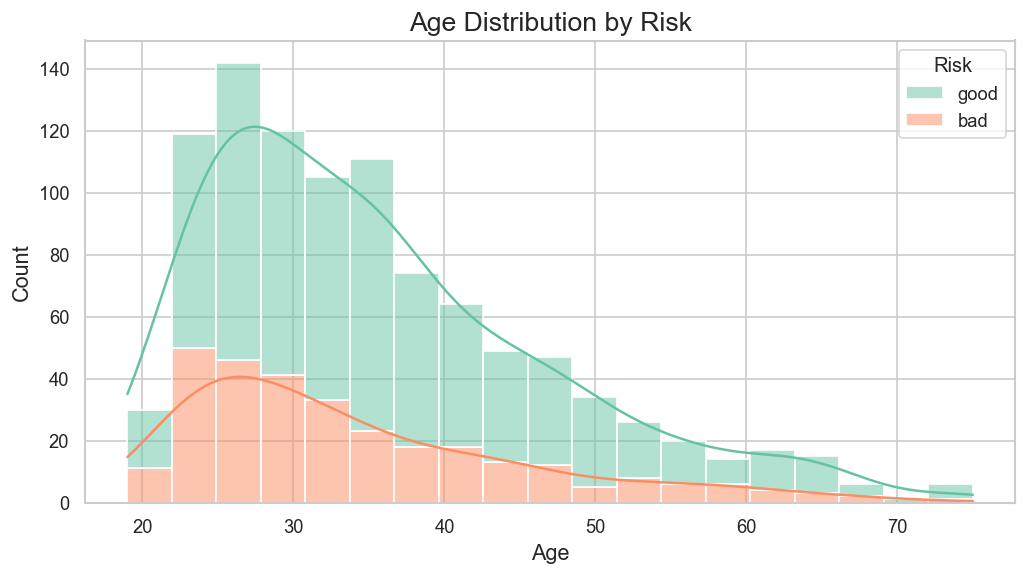

In [19]:
# ==========================================================
# Age Distribution by Risk
# ==========================================================

plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Age",
    hue="Risk",
    kde=True,
    multiple="stack"
)

plt.title("Age Distribution by Risk")

plt.show()